### Part 1
#### 1.1 
Using the following pre-trained BERT model https://huggingface.co/google-bert/bert-base-uncased,
fit a ridge model on the embeddings as you did in 3.1 to predict across voxels.

##### 1.1.1 embedding

In [2]:
"""
Loads the pretrained MLM encoder model and the raw text dataset.

- Initializes the tokenizer and encoder architecture.
- Loads the trained encoder weights from checkpoint.
- Loads the raw story text data for downstream feature generation.
"""

import torch
from transformers import BertTokenizer, BertModel, BertTokenizerFast
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Use pre-trained BERT model
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased').to(device)
bert.eval()
print("Loaded trained Encoder checkpoint successfully.")

# Load raw_text.pkl
import pickle
raw_test_path = Path("/ocean/projects/mth240012p/shared/data/raw_text.pkl")
with open(raw_test_path, 'rb') as f:
    raw_text = pickle.load(f)

print(f"Loaded {len(raw_text)} stories.")

/jet/home/xzhan/.conda/envs/env_214/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loaded trained Encoder checkpoint successfully.
Loaded 109 stories.


/var/tmp/ipykernel_52907/3662773012.py:26: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  raw_text = pickle.load(f)


In [3]:
import os
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Your own modules
from data import TextDataset
from preprocessing import downsample_word_vectors, make_delayed

def generate_word_level_bert_features(raw_text, tokenizer, model, device, max_len=16, batch_size=256):
    """
    Extracts [CLS] embeddings from Huggingface BERT for each word.
    """
    word_vectors = {}

    for story_id, seq in tqdm(raw_text.items(), desc="Encoding stories w/ BERT"):
        words = seq.data  # list of words
        embeddings_list = []

        for start_idx in range(0, len(words), batch_size):
            end_idx = min(start_idx + batch_size, len(words))
            batch_words = words[start_idx:end_idx]

            encodings = tokenizer(
                batch_words,
                padding="max_length",
                truncation=True,
                max_length=max_len,
                return_tensors="pt"
            ).to(device)

            with torch.no_grad():
                outputs = model(**encodings)  # shape: (batch_size, seq_len, hidden)
                embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token

            embeddings_list.append(embeddings.cpu().numpy())

        story_embedding = np.concatenate(embeddings_list, axis=0)
        word_vectors[story_id] = story_embedding

    return word_vectors

def generate_word_level_encoder_features(raw_text, tokenizer, encoder, device, max_len=16, batch_size=256):
    """
    Generates word-level encoder embeddings for each story, using small batches to avoid CUDA OOM.

    Args:
        raw_text: dict of story_id -> DataSequence
        tokenizer: Huggingface tokenizer
        encoder: trained encoder model
        device: cpu or cuda
        max_len: Maximum token length per word
        batch_size: Batch size for feeding into encoder to save memory

    Returns:
        word_vectors: dict of story_id -> [num_words, hidden_size]
    """
    encoder.eval()
    word_vectors = {}

    for story_id, seq in tqdm(raw_text.items(), desc="Encoding stories"):
        words = seq.data  # list of words
        embeddings_list = []  # collect all batch outputs here

        for start_idx in range(0, len(words), batch_size):
            end_idx = min(start_idx + batch_size, len(words))
            batch_words = words[start_idx:end_idx]

            # Tokenize a small batch
            encodings = tokenizer(
                batch_words,
                padding="max_length",
                truncation=True,
                max_length=max_len,
                return_tensors="pt"
            )

            input_ids = encodings["input_ids"].to(device)
            token_type_ids = encodings["token_type_ids"].to(device)
            attention_mask = encodings["attention_mask"].unsqueeze(1).unsqueeze(1).to(device)

            with torch.no_grad():
                outputs = encoder(input_ids, token_type_ids, attention_mask, output_logits=False)  # (batch_size, seq_len, hidden_size)

            # Take the CLS token's output
            embeddings = outputs[:, 0, :]  # (batch_size, hidden_size)

            embeddings_list.append(embeddings.cpu().numpy())

        # After all batches are processed, concatenate embeddings
        story_embedding = np.concatenate(embeddings_list, axis=0)  # (num_words, hidden_size)

        word_vectors[story_id] = story_embedding

    return word_vectors


def downsample_features(word_level_features, raw_text):
    """
    Downsamples word-level encoder features to match the fMRI time resolution (TR-level).

    Args:
        word_level_features (dict): Dictionary mapping story IDs to word-level feature arrays.
        raw_text (dict): Dictionary mapping story IDs to raw text sequences.

    Returns:
        dict: Dictionary mapping story IDs to TR-level downsampled feature arrays.
    """
    story_ids = list(word_level_features.keys())
    downsampled = downsample_word_vectors(
        stories=story_ids,
        word_vectors=word_level_features,
        wordseqs=raw_text
    )
    return downsampled

def trim_features(downsampled_features, TR=1, skip_seconds=(5, 10)):
    """
    Trims the beginning and end of downsampled features to remove unstable fMRI signal periods.

    Args:
        downsampled_features (dict): Dictionary of TR-level feature arrays per story.
        TR (int, optional): Time resolution (seconds per TR). Default is 1.
        skip_seconds (tuple, optional): Seconds to trim at the start and end. Default is (5, 10).

    Returns:
        dict: Dictionary of trimmed feature arrays.
    """
    trim_start = int(skip_seconds[0] / TR)
    trim_end = int(skip_seconds[1] / TR)

    trimmed = {}
    for story_id, X in downsampled_features.items():
        if X.shape[0] > (trim_start + trim_end):
            X_trimmed = X[trim_start:-trim_end]
            trimmed[story_id] = X_trimmed
        else:
            print(f"Skipped {story_id}: too short after trimming ({X.shape[0]} rows)")

    return trimmed

def apply_delays(trimmed_features, delays=range(1, 5)):
    """
    Applies temporal delays to the trimmed features to account for hemodynamic response lag.

    Args:
        trimmed_features (dict): Dictionary of trimmed TR-level feature arrays per story.
        delays (iterable, optional): Delays (in TRs) to apply. Default is range(1, 5).

    Returns:
        dict: Dictionary of delay-embedded feature arrays.
    """
    delayed = {}
    for story_id, X in trimmed_features.items():
        X_delayed = make_delayed(X, delays=delays)
        delayed[story_id] = X_delayed
    return delayed

In [4]:
story_to_X_words = generate_word_level_bert_features(raw_text, tokenizer, bert, device)

Encoding stories w/ BERT: 100%|██████████| 109/109 [00:19<00:00,  5.60it/s]


In [5]:
for i, (story_id, X) in enumerate(story_to_X_words.items()):
    print(f"{story_id}: word-level shape = {X.shape}")
    if i >= 9:
        break

sweetaspie: word-level shape = (697, 768)
thatthingonmyarm: word-level shape = (2073, 768)
tildeath: word-level shape = (2297, 768)
indianapolis: word-level shape = (1554, 768)
lawsthatchokecreativity: word-level shape = (2084, 768)
golfclubbing: word-level shape = (1211, 768)
jugglingandjesus: word-level shape = (887, 768)
shoppinginchina: word-level shape = (1731, 768)
cocoonoflove: word-level shape = (1984, 768)
hangtime: word-level shape = (1927, 768)


In [6]:
story_to_X_ds = downsample_features(story_to_X_words, raw_text)
for i, (story_id, X) in enumerate(story_to_X_ds.items()):
    print(f"{story_id}: downsample shape = {X.shape}")
    if i >= 9:
        break

sweetaspie: downsample shape = (172, 768)
thatthingonmyarm: downsample shape = (449, 768)
tildeath: downsample shape = (338, 768)
indianapolis: downsample shape = (317, 768)
lawsthatchokecreativity: downsample shape = (449, 768)
golfclubbing: downsample shape = (216, 768)
jugglingandjesus: downsample shape = (208, 768)
shoppinginchina: downsample shape = (352, 768)
cocoonoflove: downsample shape = (444, 768)
hangtime: downsample shape = (339, 768)


In [7]:
story_to_X_trimmed = trim_features(story_to_X_ds)
for i, (story_id, X) in enumerate(story_to_X_trimmed.items()):
    print(f"{story_id}: trim shape = {X.shape}")
    if i >= 9:
        break

sweetaspie: trim shape = (157, 768)
thatthingonmyarm: trim shape = (434, 768)
tildeath: trim shape = (323, 768)
indianapolis: trim shape = (302, 768)
lawsthatchokecreativity: trim shape = (434, 768)
golfclubbing: trim shape = (201, 768)
jugglingandjesus: trim shape = (193, 768)
shoppinginchina: trim shape = (337, 768)
cocoonoflove: trim shape = (429, 768)
hangtime: trim shape = (324, 768)


In [8]:
story_to_X_lagged = apply_delays(story_to_X_trimmed, delays=range(1, 5))
for i, (story_id, X) in enumerate(story_to_X_lagged.items()):
    print(f"{story_id}: lagged shape = {X.shape}")
    if i >= 9:
        break

sweetaspie: lagged shape = (157, 3072)
thatthingonmyarm: lagged shape = (434, 3072)
tildeath: lagged shape = (323, 3072)
indianapolis: lagged shape = (302, 3072)
lawsthatchokecreativity: lagged shape = (434, 3072)
golfclubbing: lagged shape = (201, 3072)
jugglingandjesus: lagged shape = (193, 3072)
shoppinginchina: lagged shape = (337, 3072)
cocoonoflove: lagged shape = (429, 3072)
hangtime: lagged shape = (324, 3072)


In [9]:
X_lagged_bert = story_to_X_lagged.copy()

##### 1.1.2 ridge regression

In [10]:
# Ridge

# import required package

import numpy as np
import joblib
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
import sys
import importlib.util
import os
"""
Loads embedding features, brain response data, and ridge regression utilities for modeling.

- Loads delay-embedded features from file.
- Loads fMRI response data for Subject 2 and Subject 3.
- Dynamically loads ridge regression functions from the provided utilities.
- Prepares input dictionaries for subsequent regression analysis.
"""

embedding_dir = Path("data")
subject2_dir = Path("/jet/home/xzhan/tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject2")
subject3_dir = Path("/jet/home/xzhan/tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject3")
ridge_py_path = Path("ridge_utils/ridge.py")
ridge_utils_dir = Path("ridge_utils") 

sys.path.append(str(ridge_utils_dir))

spec = importlib.util.spec_from_file_location("ridge", ridge_py_path)
ridge = importlib.util.module_from_spec(spec)
sys.modules["ridge"] = ridge
spec.loader.exec_module(ridge)
bootstrap_ridge = ridge.bootstrap_ridge

X = X_lagged_bert
X_dict = {"Self":X}

from tqdm import tqdm

def load_subject_data(subject_dir):
    file_list = list(subject_dir.glob("*.npy"))
    print(f" Found {len(file_list)} files in {subject_dir}")
    
    data = {}
    for f in tqdm(file_list, desc=f"Loading {subject_dir.name}"):
        try:
            data[f.stem] = np.load(f)
        except Exception as e:
            print(f" Failed to load {f.name}: {e}")
    return data

Y_subject2 = load_subject_data(subject2_dir)
Y_subject3 = load_subject_data(subject3_dir)

 Found 101 files in /jet/home/xzhan/tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject2


Loading subject2: 100%|██████████| 101/101 [00:07<00:00, 12.80it/s]


 Found 101 files in /jet/home/xzhan/tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject3


Loading subject3: 100%|██████████| 101/101 [00:07<00:00, 12.71it/s]


In [11]:
print("\n Embedding features (X_dict['Self'])")
print(f"  Number of stories: {len(X_dict['Self'])}")
print(f"  Story keys: {list(X_dict['Self'].keys())[:5]}")

print("\n Subject 2 response (Y_subject2)")
print(f"  Number of stories: {len(Y_subject2)}")
print(f"  Story keys: {list(Y_subject2.keys())[:5]}")

print("\n Subject 3 response (Y_subject3)")
print(f"  Number of stories: {len(Y_subject3)}")
print(f"  Story keys: {list(Y_subject3.keys())[:5]}")


 Embedding features (X_dict['Self'])
  Number of stories: 109
  Story keys: ['sweetaspie', 'thatthingonmyarm', 'tildeath', 'indianapolis', 'lawsthatchokecreativity']

 Subject 2 response (Y_subject2)
  Number of stories: 101
  Story keys: ['stumblinginthedark', 'singlewomanseekingmanwich', 'theclosetthatateeverything', 'jugglingandjesus', 'threemonths']

 Subject 3 response (Y_subject3)
  Number of stories: 101
  Story keys: ['stumblinginthedark', 'singlewomanseekingmanwich', 'theclosetthatateeverything', 'jugglingandjesus', 'threemonths']


In [12]:
"""
Performs ridge regression modeling and evaluation across embeddings, subjects, and stories.

- Standardizes (z-scores) the input features and brain responses.
- Splits data into training and testing sets (80/20 split).
- Performs bootstrap ridge regression with cross-validation over a grid of alpha values.
- Accumulates voxel-level correlation coefficients (CCs) across all tasks.
- Records mean CCs for each (embedding type, subject, story) triplet into a results DataFrame.
"""
from time import time
import pandas as pd
from tqdm import tqdm

results = []
all_corrs = []

# Standardize (z-score) each feature column
def zs(v):
    std = v.std(axis=0)
    std[std == 0] = 1
    return (v - v.mean(axis=0)) / std

# Iterate over each embedding type (e.g., "glove", "bert", "encoder")
for x_key, x_data in X_dict.items():

    for subj_key, y_data in [("subj2", Y_subject2), ("subj3", Y_subject3)]:

        shared_stories = sorted(list(set(x_data.keys()) & set(y_data.keys())))
        print(f"\n Starting: Embedding = {x_key}, Subject = {subj_key}, Total = {len(shared_stories)} stories")

        # Progress bar over stories
        for story in tqdm(shared_stories, desc=f"{x_key}-{subj_key}", ncols=100):

            X = x_data[story]
            Y = y_data[story]

            if X.shape[0] != Y.shape[0]:
                continue  # silently skip mismatched cases

            try:
                X_z = zs(X)
                Y_z = zs(Y)
                X_train, X_test, Y_train, Y_test = train_test_split(X_z, Y_z, test_size=0.2, random_state=42)
                alphas = np.logspace(0, 3, 20)

                wt, corrs, valalphas, _, _ = bootstrap_ridge(
                    X_train, Y_train, X_test, Y_test,
                    alphas=alphas, nboots=10, chunklen=10, nchunks=2,
                    return_wt=True
                )

                all_corrs.extend(corrs)
                results.append((x_key, subj_key, story, float(np.mean(corrs))))

            except Exception:
                continue  # silently skip any errors


 Starting: Embedding = Self, Subject = subj2, Total = 101 stories


Self-subj2:  17%|████████▍                                         | 17/101 [03:52<20:29, 14.64s/it]/jet/home/xzhan/.conda/envs/env_214/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
Self-subj2: 100%|█████████████████████████████████████████████████| 101/101 [22:31<00:00, 13.38s/it]



 Starting: Embedding = Self, Subject = subj3, Total = 101 stories


Self-subj3: 100%|█████████████████████████████████████████████████| 101/101 [22:15<00:00, 13.22s/it]


Mean CC: 0.04480615329363136
Median CC: 0.042251259760375824
Top 5% Quantile: 0.2775186966061815
Top 1% Quantile: 0.3834249775580993

 Embedding: Self


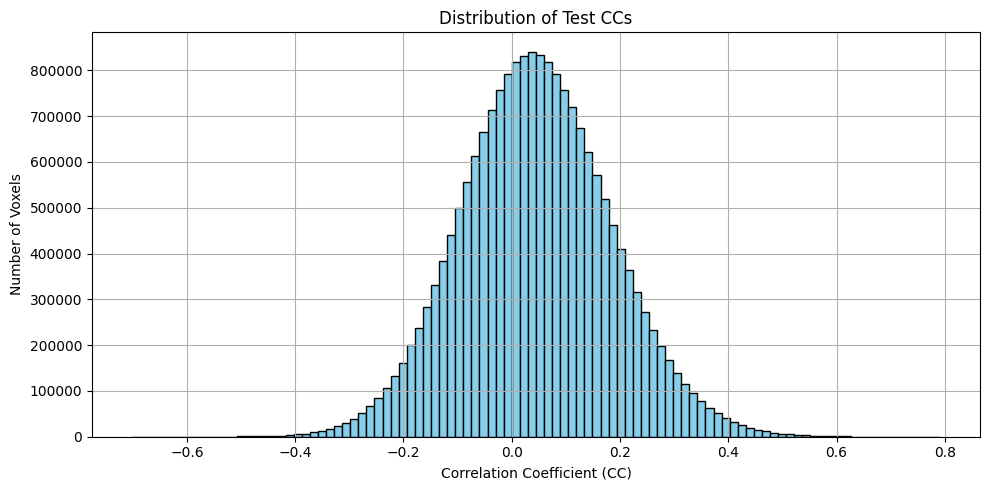


 Stability Analysis: Comparing Subject2 vs Subject3
Self: Subject2 mean=0.0443, Subject3 mean=0.0453


In [13]:
df = pd.DataFrame(results, columns=["X_type", "subject", "story", "mean_cc"])
#Summary 
print("Mean CC:", np.mean(all_corrs))
print("Median CC:", np.median(all_corrs))
print("Top 5% Quantile:", np.quantile(all_corrs, 0.95))
print("Top 1% Quantile:", np.quantile(all_corrs, 0.99))
embedding = df.groupby("X_type")["mean_cc"].mean().idxmax()
print(f"\n Embedding: {embedding}")

# Make Distribution of Test CCs
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(all_corrs, bins=100, color='skyblue', edgecolor='black')
plt.title(f"Distribution of Test CCs")
plt.xlabel("Correlation Coefficient (CC)")
plt.ylabel("Number of Voxels")
plt.grid(True)
plt.tight_layout()
plt.savefig("distribution.png", dpi=300)
plt.show()
print("\n Stability Analysis: Comparing Subject2 vs Subject3")
for emb in df["X_type"].unique():
    subj2_mean = df[(df["X_type"] == emb) & (df["subject"] == "subj2")]["mean_cc"].mean()
    subj3_mean = df[(df["X_type"] == emb) & (df["subject"] == "subj3")]["mean_cc"].mean()
    print(f"{emb}: Subject2 mean={subj2_mean:.4f}, Subject3 mean={subj3_mean:.4f}")

Results:

Mean CC: 0.04480615329363136
Median CC: 0.042251259760375824
Top 5% Quantile: 0.2775186966061815
Top 1% Quantile: 0.3834249775580993